# Very Simple On-Policy Distillation

A teacher knows how to move a 1D state toward zero. A small student learns by asking the teacher about states that the **student itself visits**.

## 1. Import the tools
Run this cell first. PyTorch trains the student and Matplotlib draws the result.

In [34]:
import torch
import matplotlib.pyplot as plt

## 2. Make the example repeatable
A fixed seed makes the random starting states and initial model weights repeatable.

In [35]:
torch.manual_seed(0)

## 3. Define the teacher
The teacher returns an action opposite to the state, so every action moves the state halfway toward zero.

In [36]:
def teacher(state):
    return -0.5 * state

## 4. Create the student
This small neural network receives one state number and predicts one action number.

In [37]:
student = torch.nn.Sequential(torch.nn.Linear(1, 16), torch.nn.Tanh(), torch.nn.Linear(16, 1))

## 5. Choose the loss and optimizer
MSE loss penalizes the squared difference between student and teacher actions. Adam updates the student weights.

In [38]:
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(student.parameters(), lr=0.01)

## 6. Set the training size
Each epoch starts 64 short rollouts. The student takes 8 actions in each rollout.

In [39]:
epochs, batch_size, rollout_steps = 200, 64, 8
losses = []

## 7. Train with on-policy states
The important line is `state = state + student_action.detach()`: the next training state is produced by the current student, not copied from a fixed dataset.

In [40]:
for e in range(epochs):
    current_state = torch.empty(batch_size, 1).uniform_(-4,4)
    epoch_loss = 0.0
    
    for steps in range(rollout_steps):
        student_action = student(current_state)
        teacher_action = teacher(current_state)
        loss = loss_fn(student_action, teacher_action)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        current_state = current_state + student_action.detach()
    losses.append(epoch_loss / rollout_steps)

## 8. Check the training loss
Run this plot after training. A falling curve means the student is matching the teacher more closely.

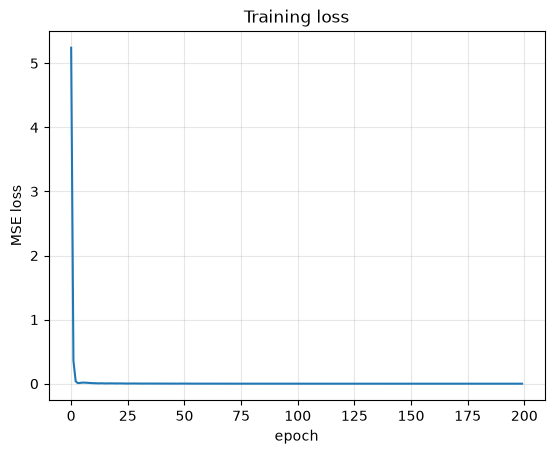

In [41]:
plt.plot(losses); plt.xlabel('epoch'); plt.ylabel('MSE loss'); plt.title('Training loss'); plt.grid(alpha=.3); plt.show()

## 9. Run the trained student
Start at 4 and repeatedly apply the student's action. A successful trajectory approaches zero.

In [42]:
state, trajectory = torch.tensor([[4.0]]), []
for _ in range(10): trajectory.append(state.item()); state = state + student(state).detach()

## 10. View the rollout
The dashed line is the goal. The points show the states visited by the trained student.

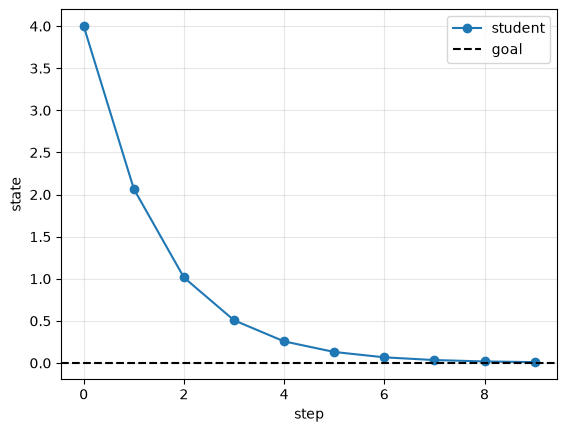

In [43]:
plt.plot(trajectory, 'o-', label='student'); plt.axhline(0, color='black', ls='--', label='goal'); plt.xlabel('step'); plt.ylabel('state'); plt.legend(); plt.grid(alpha=.3); plt.show()